# Notebook \#3: Modelling

# Eviny Charging Curve Classification LSTM 
#### by Sebastian Einar Salas Røkholt
----

### Index
**01 - Setup** </br>
**02 - Data Exploration, Wrangling and Preprocessing**</br>
**03 - Modelling**</br>
**04 - Model Evaluation and Selection**</br>
**+++**</br>

## 01 - Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, GroupShuffleSplit
RANDOM_SEED = 42

In [2]:
# Load the cleaned dataset with engineered features (minutes_elapsed, temp)
df = pd.read_parquet("../Data/etron55-charging-sessions.parquet")
# Select the columns that are relevant for predicting SOC and Power at each timestep
df = df[["charging_id", "minutes_elapsed", "power", "soc", "temp", "nominal_power"]]
df.head()

,charging_id,minutes_elapsed,power,soc,temp,nominal_power
0,0,0,89.44,40.0,4,150.0
1,0,1,92.75,41.0,4,150.0
2,0,2,94.81,43.0,4,150.0
3,0,3,95.68,45.0,4,150.0
4,0,4,96.88,47.0,4,150.0


## 02 - Preparing the dataset for modelling

In [3]:
# Splitting the data into training, validation and test sets
# def split_data(df, test_size=0.2, validation_size=0.1):
#     train_val_df, test_df = train_test_split(df, test_size=test_size, shuffle=False, stratify=None)
#     validation_size = validation_size / (1 - test_size)  # Adjust validation size based on the remaining dataset after test split
#     train_df, val_df = train_test_split(train_val_df, test_size=validation_size, shuffle=False)
#     return train_df, val_df, test_df

# Splitting the data into training, validation and test sets
# GroupShuffleSplit ensures that a charging session isn't split across multiple sets
def split_data(df, test_size=0.2, validation_size=0.1):
    # Defines the test split
    gss_test = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=RANDOM_SEED)
    train_val_idx, test_idx = next(gss_test.split(df, groups=df['charging_id']))
    train_val_df = df.iloc[train_val_idx]

    # Defines the validation split
    validation_size = validation_size / (1 - test_size)  # Adjust validation size based on the remaining dataset after test split
    gss_val = GroupShuffleSplit(n_splits=1, test_size=validation_size, random_state=RANDOM_SEED)
    train_idx, val_idx = next(gss_val.split(train_val_df, groups=train_val_df['charging_id']))

    # Performs the splits on the original dataset
    train_df = train_val_df.iloc[train_idx]
    val_df = train_val_df.iloc[val_idx]
    test_df = df.iloc[test_idx]
    return train_df, val_df, test_df

train_df, val_df, test_df = split_data(df)

In [4]:
# Performs data normalisation
features = ['minutes_elapsed', 'power', 'soc', 'temp', 'nominal_power']
scaler = MinMaxScaler(feature_range=(0, 1))
train_df[features] = scaler.fit_transform(train_df[features])  # Only fits the scaler on training data (Prevents info leakage)
val_df[features] = scaler.transform(val_df[features])
test_df[features] = scaler.transform(test_df[features])

/tmp/ipykernel_28417/2938056454.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df[features] = scaler.transform(test_df[features])


In [5]:
# For creating sequences (charging sessions) to feed into the LSTM
def create_sequences(df, sequence_length=5):
    all_xs = []
    all_ys = []
    for session_id, session_df in df.groupby('charging_id', observed=False):
        session_features = session_df[features].values
        session_targets = session_df[['power', 'soc']].values

        xs, ys = [], []
        for i in range(len(session_features) - sequence_length):
            x = session_features[i:(i + sequence_length)]
            y = session_targets[i + sequence_length]
            xs.append(x)
            ys.append(y)

        all_xs.extend(xs)
        all_ys.extend(ys)
    
    return np.array(all_xs), np.array(all_ys)

# Create sequences for each set
sequence_length = 15  # Lookback window for predictions will be 15 time steps/minutes
X_train, y_train = create_sequences(train_df, sequence_length)
X_val, y_val = create_sequences(val_df, sequence_length)
X_test, y_test = create_sequences(test_df, sequence_length)

In [6]:
print(f"First 5 training sequences: \n(Columns are {features}\n{X_train[:5]}")
print("\n\nTrue output for first 5 training sequences:\n", y_train[:5],)

First 5 training sequences: 
(Columns are ['minutes_elapsed', 'power', 'soc', 'temp', 'nominal_power']
[[[0.         0.33399305 0.39393939 0.56451613 0.22222222]
  [0.00653595 0.34635349 0.4040404  0.56451613 0.22222222]
  [0.0130719  0.35404608 0.42424242 0.56451613 0.22222222]
  [0.01960784 0.3572949  0.44444444 0.56451613 0.22222222]
  [0.02614379 0.36177602 0.46464646 0.56451613 0.22222222]
  [0.03267974 0.36453938 0.47474747 0.56451613 0.22222222]
  [0.03921569 0.36920721 0.49494949 0.56451613 0.22222222]
  [0.04575163 0.37185855 0.51515152 0.56451613 0.22222222]
  [0.05228758 0.37238134 0.53535354 0.56451613 0.22222222]
  [0.05882353 0.37226932 0.54545455 0.56451613 0.22222222]
  [0.06535948 0.37189589 0.56565657 0.56451613 0.22222222]
  [0.07189542 0.37152246 0.58585859 0.56451613 0.22222222]
  [0.07843137 0.37570484 0.60606061 0.56451613 0.22222222]
  [0.08496732 0.3759289  0.61616162 0.56451613 0.22222222]
  [0.09150327 0.37589156 0.63636364 0.56451613 0.22222222]]

 [[0.00653

In [7]:
batch_size = 128
num_workers = 16

# Converts from Numpy arrays to PyTorch tensors
train_features = torch.Tensor(X_train)
train_targets = torch.Tensor(y_train)
val_features = torch.Tensor(X_val)
val_targets = torch.Tensor(y_val)

# Creates TensorDatasets
train_dataset = TensorDataset(train_features, train_targets)
val_dataset = TensorDataset(val_features, val_targets)

# Creates DataLoaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)

## Modelling

In [8]:
# Defines the general model architecture and the forward pass
class MultivariateLSTM(nn.Module):
    def __init__(self, input_size, hidden_layer_size, output_size, num_layers):
        super(MultivariateLSTM, self).__init__()
        self.hidden_layer_size = hidden_layer_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size, hidden_layer_size, num_layers, batch_first=True)
        self.linear = nn.Linear(hidden_layer_size, output_size)

    # Forward propagation
    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_layer_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_layer_size).to(x.device)
        
        # LSTM layer output
        out, _ = self.lstm(x, (h0, c0))
        
        # Last time step hidden state
        out = self.linear(out[:, -1, :])
        return out


In [9]:
# Defines the training loop (gradient descent + backpropagation)
def train_model(model, train_loader, val_loader, num_epochs=100, learning_rate=0.0001, plot_loss=True):
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    model.train()
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    # Define a scheduler that reduces the LR by a factor of 0.1 if the validation loss doesn't improve for 5 epochs
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=5, verbose=True)

    
    if plot_loss == True:
        # For plotting
        train_losses = list()
        val_losses = list()
    
    # Runs the training loop
    for epoch in range(num_epochs):  # For every pass through the entire dataset
        epoch_train_loss, epoch_val_loss = 0.0, 0.0
        
        for inputs, labels in train_loader:  # For every batch
            inputs, labels = inputs.to(device), labels.to(device)  # Moves data to the training device
            optimizer.zero_grad()  # (Re)sets gradients to 0 so that they don't compound
            outputs = model(inputs)  # Forward pass / Runs predictions
            train_loss = criterion(outputs, labels)  # Calculate the batch loss
            epoch_train_loss += train_loss.item()  # Add loss to this epoch's total training loss
            train_loss.backward()  # Calculates the gradient of the loss function wrt params with backpropagation
            optimizer.step()  # Updates the model parameters based on the gradient, step size and optimization strategy
        
        # For printing the validation loss during training
        model.eval()  # Set model to evaluation mode
        with torch.no_grad():  # No learning here
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                val_loss = criterion(outputs, labels)
                epoch_val_loss += val_loss.item()
        
        # Averages the loss per epoch
        avg_epoch_val_loss = epoch_val_loss / len(val_loader)
        avg_epoch_train_loss = epoch_train_loss / len(train_loader)

        # Steps the scheduler
        scheduler.step(avg_epoch_val_loss)

        # Print the epoch's average loss every 5 epochs
        if (epoch + 1) % 5 == 0: 
            curr_lr = optimizer.param_groups[0]["lr"]
            print(f'Epoch {epoch+1}, LR: {curr_lr}, Training loss: {avg_epoch_train_loss},'
                  f'Validation Loss: {avg_epoch_val_loss}')
        # if plot_loss == True and epoch > 5:  # I don't want to plot the first few epochs because loss is very high
        #     # Store loss for plotting purposes
        #     train_losses.append(avg_epoch_train_loss)
        #     val_losses.append(avg_epoch_val_loss)

        model.train()  # Set model back to train mode before loading next batch
    
    print('Training complete.')

    if plot_loss == True: 
        # Create a DataFrame from the loss lists
        data = {
            'Epoch': range(1, len(train_losses) + 1),
            'Training Loss': train_losses,
            'Validation Loss': val_losses
        }
        df_losses = pd.DataFrame(data).melt(id_vars=["Epoch"], var_name="Type", value_name="Loss")

        # Plot using Seaborn
        plt.figure(figsize=(10, 6))
        sns.lineplot(data=df_losses, x='Epoch', y='Loss', hue='Type')
        plt.title('Training and Validation Loss Over Number of Training Epochs')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend(title='Loss type')
        plt.show()


In [10]:
# Setting the model hyperparameters
input_size = len(features)  # power, soc, minutes_elapsed, temperature and nominal power
hidden_layer_size = 60
output_size = 2  # Predicting power and soc for the next time step
num_layers = 4  # Number of LSTM layers

# Defining the network architecture and hyperparameters
model = MultivariateLSTM(input_size, hidden_layer_size, output_size, num_layers)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model.to(device)

MultivariateLSTM(
  (lstm): LSTM(5, 60, num_layers=4, batch_first=True)
  (linear): Linear(in_features=60, out_features=2, bias=True)
)

Training on cuda:0


/home/srokholt/Master's Project - Linux Environment/Machine-Teaching-for-XAI--TimeSeries-Models/linux_venv/lib64/python3.12/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 5, LR: 0.0001, Training loss: 0.00017444453844785396,Validation Loss: 0.00015688124911530474
Epoch 10, LR: 0.0001, Training loss: 0.00014058550593280312,Validation Loss: 0.00013304301994252358
Epoch 15, LR: 0.0001, Training loss: 0.00013353532179443496,Validation Loss: 0.00013309654869104166
Epoch 20, LR: 0.0001, Training loss: 0.00012755367015709527,Validation Loss: 0.00012194264282351895
Epoch 25, LR: 0.0001, Training loss: 0.00012131599097560474,Validation Loss: 0.00011858750769968425
Epoch 30, LR: 0.0001, Training loss: 0.0001176927737893833,Validation Loss: 0.00011711925473026839
Epoch 35, LR: 0.0001, Training loss: 0.00011477016081288384,Validation Loss: 0.00011334203846085058
Epoch 40, LR: 1e-05, Training loss: 0.00010728761166995198,Validation Loss: 0.0001092975180243841
Epoch 45, LR: 1e-05, Training loss: 0.00010706323708067377,Validation Loss: 0.00010893624996113801
Epoch 50, LR: 1e-05, Training loss: 0.00010685371127989295,Validation Loss: 0.00010905955371534991
Traini

/tmp/ipykernel_28417/3371172501.py:74: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Loss type')


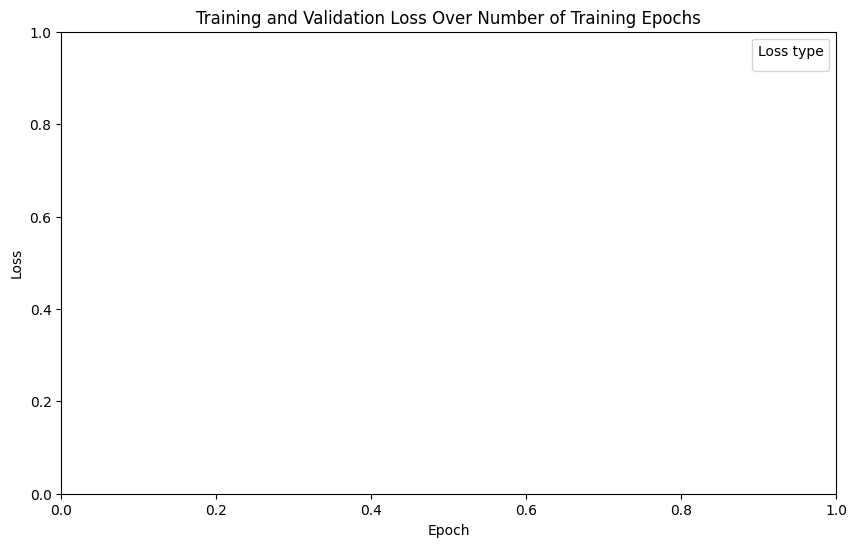

In [11]:
# Running the training loop
model_path = '../Models/LSTM_model_3.pth'
print(f"Training on {device}")
train_model(model, train_loader, val_loader, num_epochs=50, plot_loss=True)
torch.save(model.state_dict(), model_path)

## Prediction

In [12]:
# Find the longest sequence in the test data
test_session_ids = test_df["charging_id"].unique()
print(test_session_ids)

# Filter the test DataFrame for the selected session
max_id = 0
max_len = 0
for i in range(len(test_session_ids)):
    selected_sessions_id = test_session_ids[i]
    selected_sessions_df = test_df[test_df['charging_id'] == selected_sessions_id]
    if len(selected_sessions_df) > max_len:
        max_len = len(selected_sessions_df)
        max_id = selected_sessions_id

print(f"Max length: {max_len}, ID: {max_id}")

[   17906    31432    31869 ... 12645479 12649236 12657311]


Max length: 191, ID: 6087237


In [13]:
# Selecting a random charging sessions
# test_session_ids = test_df["id"].unique()

# Filter the test DataFrame for the selected sessions
# selected_sessions_id = [test_session_ids[max_id]]
max_id = 6087237
selected_sessions_df = test_df[test_df['charging_id'] == max_id]
print(len(selected_sessions_df))

# Performs normalization
# selected_sessions_df[features] = scaler.transform(selected_sessions_df[features])
# Create sequences 
X_test_selected, y_test_selected = create_sequences(selected_sessions_df, sequence_length)
print(f"Number of X sequences: {len(X_test_selected)}", f"\nNumber of y_true: {len(y_test_selected)}")
selected_sessions_df.head()

191
Number of X sequences: 176 
Number of y_true: 176


,charging_id,minutes_elapsed,power,soc,temp,nominal_power
828455,6087237,0.000000,0.083274,0.050505,0.467742,0.222222
828456,6087237,0.000000,0.128608,0.050505,0.467742,0.222222
828457,6087237,0.000000,0.130065,0.050505,0.467742,0.222222
828458,6087237,0.006536,0.128608,0.050505,0.467742,0.222222
828459,6087237,0.006536,0.128944,0.060606,0.467742,0.222222


In [14]:
print(X_test_selected[:5])
print("\n\n", X_train[:5])

[[[0.         0.08327421 0.05050505 0.46774194 0.22222222]
  [0.         0.12860824 0.05050505 0.46774194 0.22222222]
  [0.         0.1300646  0.05050505 0.46774194 0.22222222]
  [0.00653595 0.12860824 0.05050505 0.46774194 0.22222222]
  [0.00653595 0.12894432 0.06060606 0.46774194 0.22222222]
  [0.00653595 0.12894432 0.06060606 0.46774194 0.22222222]
  [0.0130719  0.12894432 0.07070707 0.46774194 0.22222222]
  [0.0130719  0.12928041 0.07070707 0.46774194 0.22222222]
  [0.0130719  0.12961649 0.07070707 0.46774194 0.22222222]
  [0.01960784 0.12961649 0.07070707 0.46774194 0.22222222]
  [0.01960784 0.12961649 0.08080808 0.46774194 0.22222222]
  [0.01960784 0.13107286 0.08080808 0.46774194 0.22222222]
  [0.02614379 0.13107286 0.08080808 0.46774194 0.22222222]
  [0.02614379 0.13140894 0.08080808 0.46774194 0.22222222]
  [0.02614379 0.13140894 0.09090909 0.46774194 0.22222222]]

 [[0.         0.12860824 0.05050505 0.46774194 0.22222222]
  [0.         0.1300646  0.05050505 0.46774194 0.22222

In [15]:
# Load the model
model.load_state_dict(torch.load(model_path))
model.eval()

/tmp/ipykernel_28417/3576574103.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path))


MultivariateLSTM(
  (lstm): LSTM(5, 60, num_layers=4, batch_first=True)
  (linear): Linear(in_features=60, out_features=2, bias=True)
)

In [16]:
# Run predictions
session_predictions = list()
with torch.no_grad():
    for sequence in X_test_selected:
        # print("Input: ", sequence)
        seq_tensor = torch.tensor(sequence, dtype=torch.float).unsqueeze(0).to(device)
        prediction = model(seq_tensor).cpu().numpy()
        # print("Prediction: ", prediction)
        session_predictions.append(prediction)

print(session_predictions)

[array([[0.13053714, 0.09552506]], dtype=float32), array([[0.13000534, 0.09770291]], dtype=float32), array([[0.12985873, 0.09972771]], dtype=float32), array([[0.1304961 , 0.10134417]], dtype=float32), array([[0.12977444, 0.10316675]], dtype=float32), array([[0.13051961, 0.10560696]], dtype=float32), array([[0.13105427, 0.10801668]], dtype=float32), array([[0.1298346 , 0.11020549]], dtype=float32), array([[0.13054724, 0.11256371]], dtype=float32), array([[0.12998246, 0.11504032]], dtype=float32), array([[0.12997738, 0.11746354]], dtype=float32), array([[0.13098726, 0.11971208]], dtype=float32), array([[0.13134347, 0.12194054]], dtype=float32), array([[0.13119708, 0.12446053]], dtype=float32), array([[0.1302189 , 0.12695694]], dtype=float32), array([[0.13005252, 0.12917942]], dtype=float32), array([[0.13143124, 0.1306188 ]], dtype=float32), array([[0.13148575, 0.13193344]], dtype=float32), array([[0.130132, 0.133621]], dtype=float32), array([[0.13134025, 0.135759  ]], dtype=float32), arr

In [17]:
pred_df = pd.DataFrame([pred[0] for pred in session_predictions], columns=["Power", "soc"])
pred_df

,Power,soc
0,0.130537,0.095525
1,0.130005,0.097703
2,0.129859,0.099728
3,0.130496,0.101344
4,0.129774,0.103167
...,...,...
171,0.136761,0.522811
172,0.138365,0.525844
173,0.138381,0.528626
174,0.138275,0.530620


In [18]:
# Reverse normalisation of predictions
pred_df["minutes_elapsed"] = selected_sessions_df.tail(len(pred_df)).minutes_elapsed.values
unscaled_pred_df = pd.DataFrame(scaler.inverse_transform(pred_df), columns=features)
display(unscaled_pred_df.head())
# Reverse normalisation of actuals
unscaled_true_df = pd.DataFrame(scaler.inverse_transform(selected_sessions_df[features]), columns=features)
display(unscaled_true_df.head())


ValueError: operands could not be broadcast together with shapes (176,3) (5,) (176,3) 

In [ ]:
display(unscaled_true_df.head(40))
display(unscaled_pred_df.head(10))


In [ ]:
# Create a figure and a set of subplots
fig, ax1 = plt.subplots()

# Plotting Power
ax1.set_xlabel('Minutes elapsed in current charging session')
ax1.set_ylabel('power')
ax1.plot(unscaled_pred_df['minutes_elapsed'], unscaled_pred_df['power'], color="darkorange", label='Predicted Power')
ax1.plot(unscaled_true_df['minutes_elapsed'], unscaled_true_df['power'], color='darkred', label='True Power', alpha=0.5)
ax1.tick_params(axis='y')


# Plotting SOC on dual axis
ax2 = ax1.twinx()
ax2.plot(unscaled_pred_df['minutes_elapsed'], unscaled_pred_df['soc'], color="darkblue", label='Predicted SOC')
ax2.plot(unscaled_true_df['minutes_elapsed'], unscaled_true_df['soc'], color='darkblue', label='True SOC', alpha=0.5)

lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left')

plt.title(f'Predictions vs. Actuals for session {max_id}')
plt.xlabel('Time Step')
plt.ylabel('Power / SOC')
# plt.legend()
plt.show()


## Anomaly Detection

In [ ]:
def detect_anomalies(model, new_data, threshold):
    model.eval()  # Ensure the model is in evaluation mode
    anomalies = []
    
    # Assuming new_data is preprocessed and in the correct format
    with torch.no_grad():
        for sequence in new_data:
            # Make prediction
            sequence = torch.tensor(sequence, dtype=torch.float).unsqueeze(0).to(device)  # Add batch dimension
            prediction = model(sequence)
            
            # Calculate error
            actual = sequence[:, -1, :2].squeeze().cpu().numpy()  # Last timestep, actual power and soc
            prediction = prediction.squeeze().cpu().numpy()
            error = np.mean((actual - prediction)**2)
            
            # Check if error exceeds threshold
            if error > threshold:
                anomalies.append((sequence.cpu().numpy(), prediction, error))
    
    return anomalies

# Example usage
threshold = 0.01  # This is an example threshold, adjust based on your error analysis
new_data = ...  # Your new data sequences, preprocessed similarly to the training data

anomalies = detect_anomalies(model, new_data, threshold)

print(f"Detected {len(anomalies)} anomalies.")
